# Cavity_Example — 腔与 TWS: 1D 腔表/TWS/3D 场图/TDS

本 notebook 是官方算例系列教学之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Cavity_Example"
STEM = "astra"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Cavity_Example | 物理: 腔与 TWS: 1D 腔表/TWS/3D 场图/TDS


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Sat Aug 15 21:56:50 

     Working File is:    generator.in                                      
     Initializing       1000      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =       1000
     total charge                      Q =    -0.1000     nC
     horizontal beam position          x =     1.8389E-04 mm
     vertical beam position            y =     1.1714E-04 mm
     longitudinal beam position        z =     3.0448E-08 m
     horizontal beam size          sig x =      1.000     mm
     vertical beam size            sig y =      1.000     mm
     longitudinal beam size        sig z =     0.9877

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: astra.0040.001

  Cavity_Example @ astra.0040.001
  Particles:           1000 total,     1000 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        0.1000 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:     108.4700 MeV/c
  Ref. kinetic E:    107.9602 MeV
  gamma:             212.2729
  beta:              0.999989
----------------------------------------
  Centroid x:          0.0002 mm
  Centroid y:          0.0001 mm
  Centroid z:        400.0000 mm
  sigma_x:             0.9619 mm
  sigma_y:             0.9619 mm
  sigma_z:             0.9877 mm
----------------------------------------
  Mean pz:           108.4561 MeV/c
  sigma_p/p:         0.000233
  Mean E_kin:        107.9463 MeV
  sigma_E:            25.2756 keV
  sigma_E/E:         0.000234
----------------------------------------
  eps_x (geom):        0.0050 um.rad
  eps_y (geom):        0.0050 um.rad
  eps_nx:              1.0

quantity,value,unit
n_particle,1000,
n_active,1000,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,0.1 (|Q|),nC
mean_x_mm,0.000177884,mm
mean_y_mm,0.000113986,mm
mean_z_mm,400,mm
sig_x_mm,0.961903,mm


### 教学要点

本例是场图大户: 1D 腔表 (3_cell_L-Band)、TWS 行波结构、3D 场图 (3D_test)。它的 golden PScan 也展示单腔余弦律。

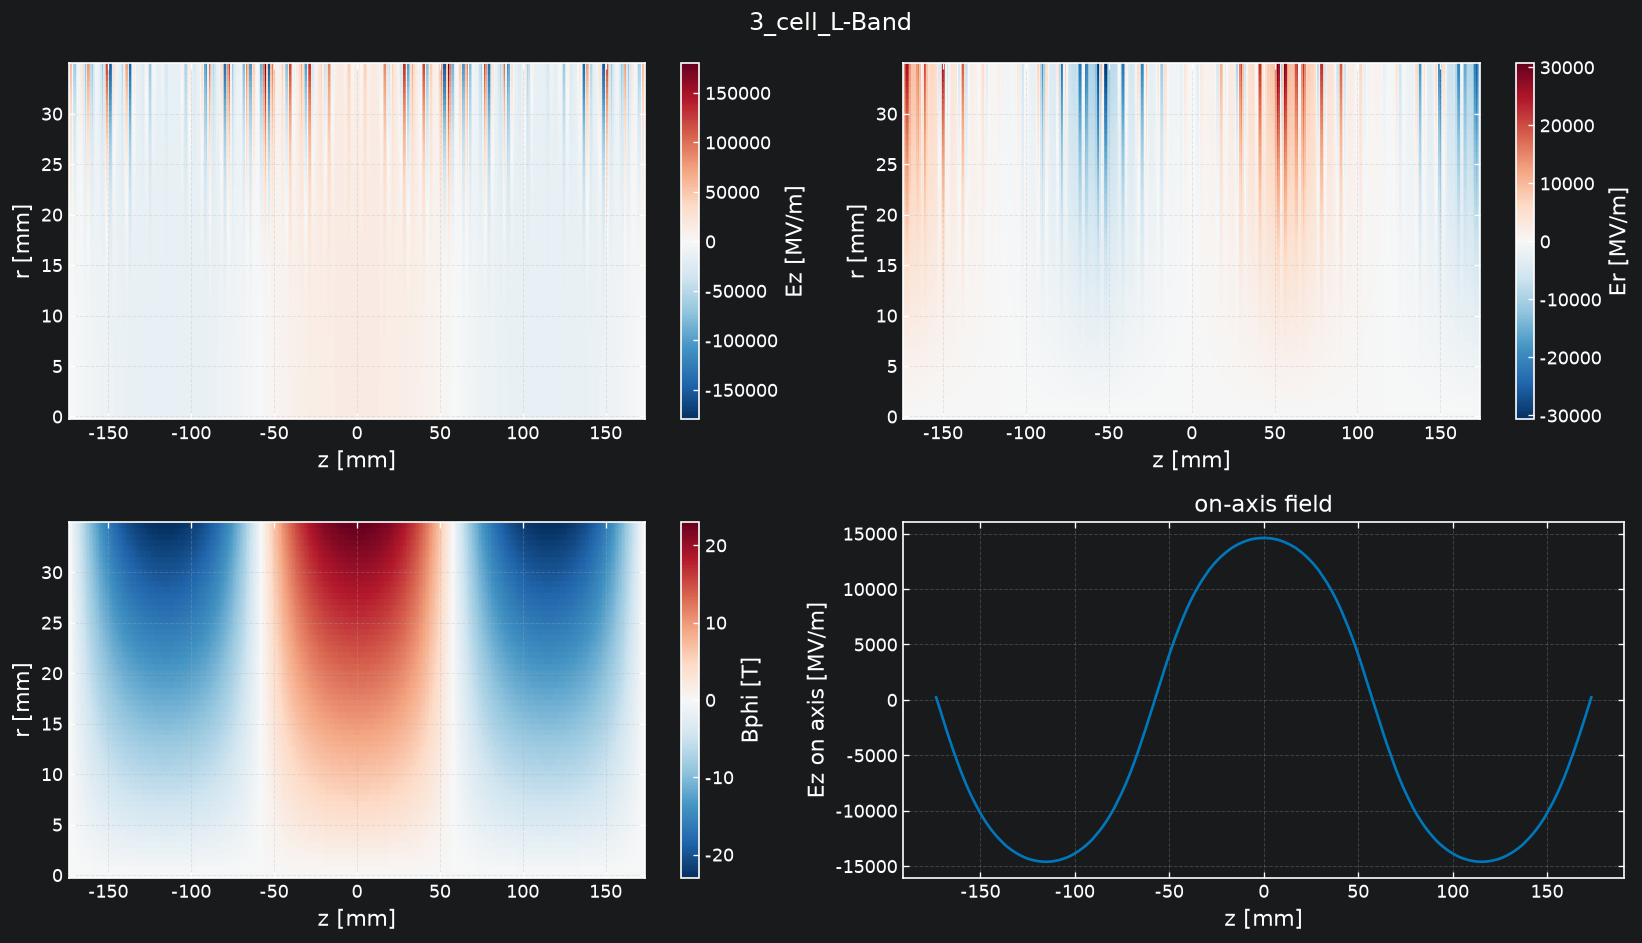

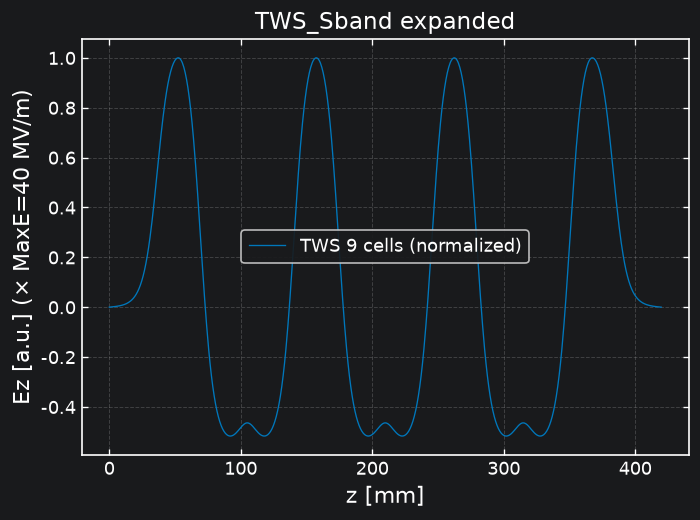

In [5]:
import numpy as _np
import matplotlib.pyplot as plt
from astra_tools.io.field_map import (read_cavity_field, parse_field_map_file,
                                       expand_tws_field_map)
from astra_tools.plot.field_plots import plot_cavity_field
cav = read_cavity_field(work / "3_cell_L-Band.dat")
plot_cavity_field(cav, omega=2 * _np.pi * 1.3e9, title="3_cell_L-Band")
# TWS 行波结构: 4 值头 (z1 z2 n m) 周期展开 (deck 里 C_numb=9)
attrs, data = parse_field_map_file(work / "TWS_Sband.dat")
zf, ff = expand_tws_field_map(data[:, 0], data[:, 1], attrs["z1"], attrs["z2"],
                              m_cells_in_body=attrs["m"], n_cell=9)
plt.figure()
plt.plot(zf * 1e3, ff, lw=0.8, label="TWS 9 cells (normalized)")
plt.xlabel("z [mm]")
plt.ylabel("Ez [a.u.] (× MaxE=40 MV/m)")
plt.title("TWS_Sband expanded")
plt.legend()
plt.tight_layout()


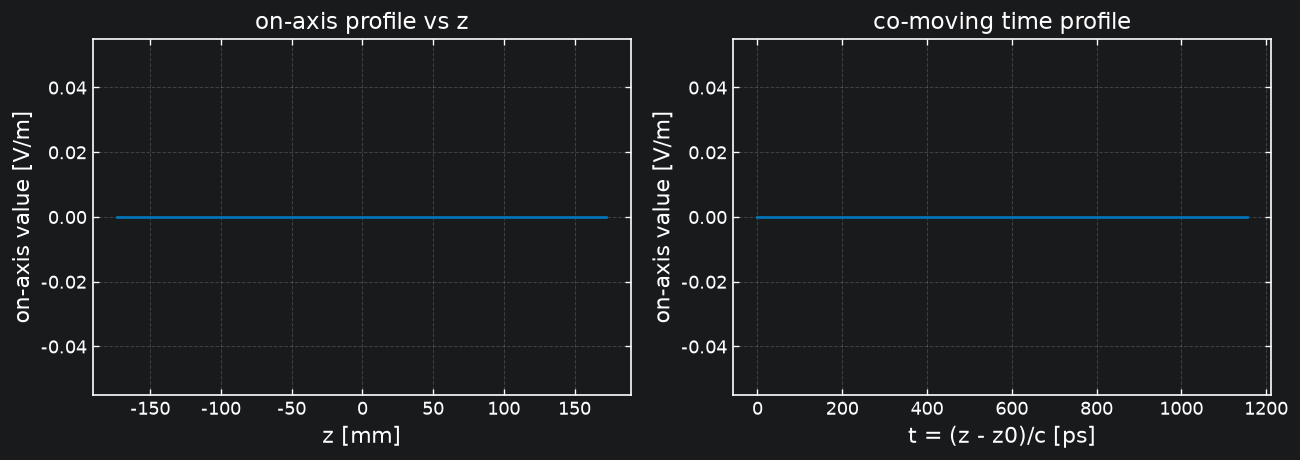

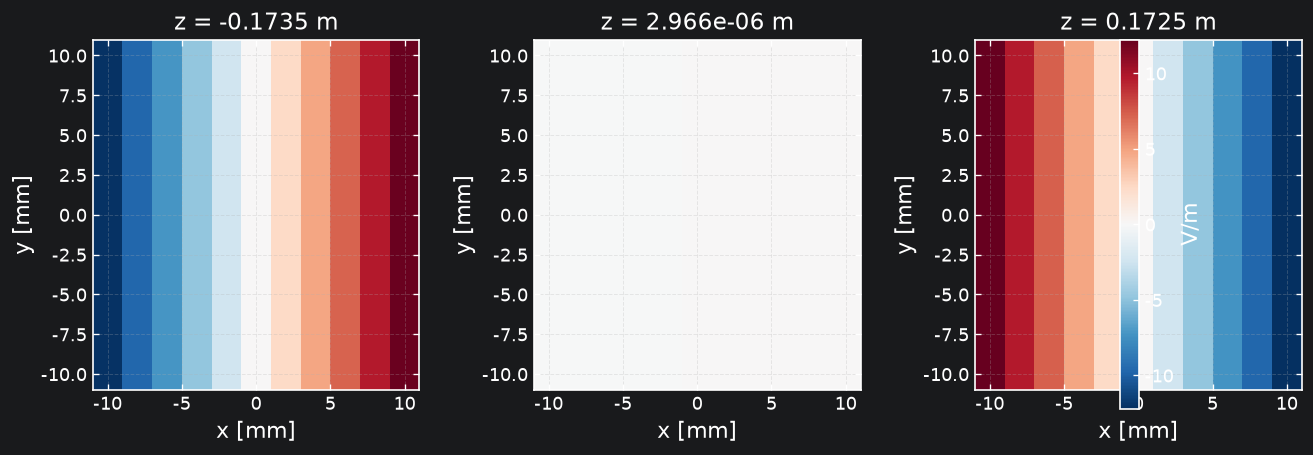

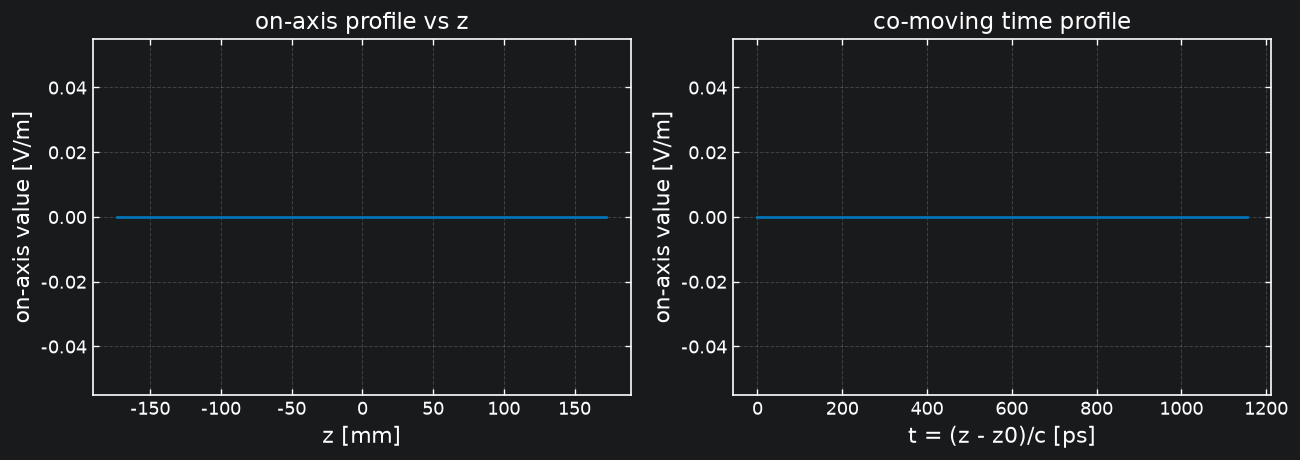

In [6]:
from astra_tools.plot.advanced_plots import plot_3d_map_slices, plot_laser_on_axis
plot_3d_map_slices(work / "3D_test.ex", axis="z", n_slices=3, unit="V/m")
plot_laser_on_axis(work / "3D_test.ex", unit="V/m")

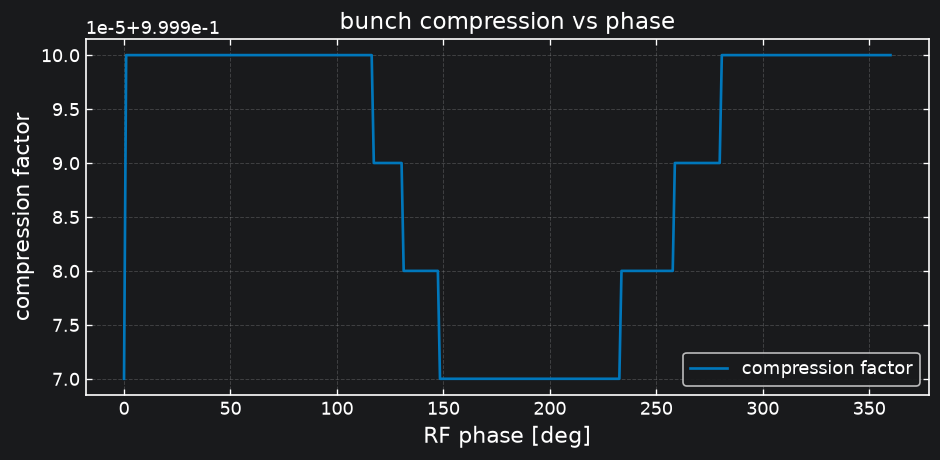

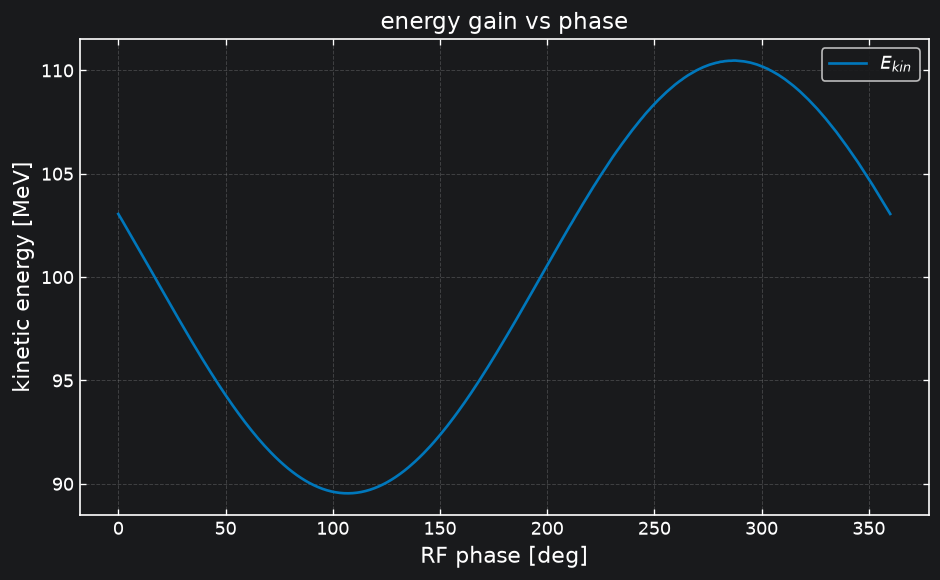

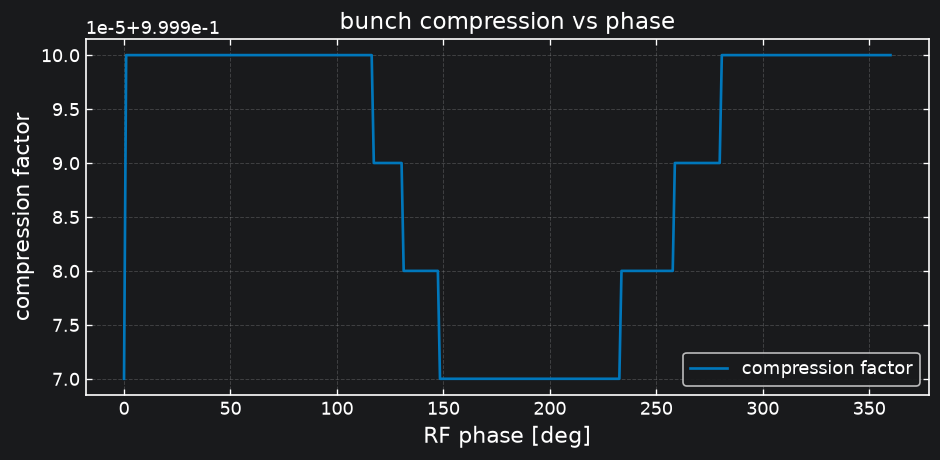

In [7]:
from astra_tools.io.astra_misc import read_pscan
from astra_tools.plot.advanced_plots import plot_phase_scan, plot_pscan_compression
pscan = read_pscan(PROJECT_ROOT / "examples/Cavity_Example/golden/astra.PScan.001")
plot_phase_scan(pscan)   # E(phi) = E0 + A cos(phi-phi0)
plot_pscan_compression(pscan)

In [8]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的教学 notebook 同样位于 examples/ 目录")

  末行比对 (new vs golden):
    norm_emit_x    1.0717e-06 1.0717e-06 rel=0.0000% OK
    sigma_x        0.0009619  0.0009619  rel=0.0000% OK
    mean_z         0.4        0.4        rel=0.0000% OK
返回汇总: notebooks/06_examples.ipynb
